# Geospatial Utilities for Planetary Images

The `planetarypy.geo` module provides coordinate transforms for planetary image data — converting between pixel coordinates, map-projected coordinates, and geographic (lon/lat) coordinates.

It is built on `rasterio` and `pyproj` (no GDAL required) and works with both Earth and planetary CRS (Mars, Moon, etc.).

In [1]:
import numpy as np
from affine import Affine

from planetarypy.geo import (
    pixel_to_xy,
    xy_to_pixel,
    pixel_to_lonlat,
    lonlat_to_pixel,
    xy_to_lonlat,
    lonlat_to_xy,
    image_azimuth,
    image_azimuth_cw_from_right,
    pixel_resolution,
)

## Pixel ↔ Map Coordinates

Every georeferenced image has an **affine transform** that maps pixel (sample, line) to map-projected (x, y) coordinates. This is a simple 2×3 matrix — no CRS needed.

In [2]:
# A Mars equirectangular image: 200 m/pixel, origin at x=-50km, y=100km
transform = Affine(200.0, 0.0, -50000.0,
                   0.0, -200.0, 100000.0)

# Pixel (100, 50) → map coordinates
x, y = pixel_to_xy(transform, sample=100, line=50)
print(f"Pixel (100, 50) → x={x:.0f} m, y={y:.0f} m")

Pixel (100, 50) → x=-29900 m, y=89900 m


In [3]:
# And back: map coordinates → pixel
s, l = xy_to_pixel(transform, x, y)
print(f"x={x:.0f}, y={y:.0f} → pixel ({s:.0f}, {l:.0f})")

x=-29900, y=89900 → pixel (100, 50)


In [4]:
# Works with arrays too — convert an entire grid of pixels
samples = np.array([0, 50, 100, 150, 200])
lines = np.array([0, 0, 0, 0, 0])
xs, ys = pixel_to_xy(transform, samples, lines)
print("Samples:", samples)
print("X coords:", xs)

Samples: [  0  50 100 150 200]
X coords: [-49900. -39900. -29900. -19900.  -9900.]


In [5]:
# Get pixel resolution from the transform
res_x, res_y = pixel_resolution(transform)
print(f"Pixel resolution: {res_x:.0f} × {res_y:.0f} m")

Pixel resolution: 200 × 200 m


## Map Coordinates ↔ Geographic (Lon/Lat)

To go from map-projected coordinates to lon/lat (or vice versa), you need a **CRS**. The `geo` module uses `pyproj` under the hood and automatically derives the correct geographic CRS from the projected CRS — so it works for any planetary body, not just Earth.

Planetary bodies use **IAU CRS codes** (supported by GDAL, ISIS, and pyproj). The convention is `IAU_2015:{body_id}XX` where the body ID follows the NAIF convention (e.g. Mars = 499, Moon = 301).

In [6]:
from pyproj import CRS as ProjCRS

# The old way: raw proj4 string (works but fragile, easy to get radius wrong)
mars_manual = ProjCRS.from_proj4("+proj=eqc +lat_ts=0 +lon_0=0 +R=3396190 +units=m")
print(f"Manual proj4: '{mars_manual.name}'")  # → 'unknown' — no metadata!

# The better way: IAU 2015 CRS codes
# 49910 = Mars (NAIF body 499) + equirectangular sphere ocentric (suffix 10)
mars_equirect = ProjCRS.from_authority("IAU_2015", 49910)
print(f"IAU code:     '{mars_equirect.name}'")

# The proj4 CRS is just math with no identity — pyproj can't even name it.
# The IAU code carries body name, projection, and datum. It's what GDAL,
# ISIS, and the PDS4 standard use. Always prefer IAU codes.

# Both produce the same coordinates:
lon, lat = xy_to_lonlat(mars_equirect, x=1_000_000, y=500_000)
print(f"\nx=1000km, y=500km → lon={lon:.2f}°, lat={lat:.2f}°")

Manual proj4: 'unknown'
IAU code:     'Mars (2015) - Sphere / Ocentric / Equirectangular, clon = 0'

x=1000km, y=500km → lon=16.87°, lat=8.44°


In [7]:
# Roundtrip: lon/lat → projected → lon/lat
x2, y2 = lonlat_to_xy(mars_equirect, lon=45.0, lat=-10.0)
lon2, lat2 = xy_to_lonlat(mars_equirect, x2, y2)
print(f"lon=45°, lat=-10° → x={x2:.0f}, y={y2:.0f} → lon={lon2:.4f}°, lat={lat2:.4f}°")

lon=45°, lat=-10° → x=2667361, y=-592747 → lon=45.0000°, lat=-10.0000°


In [8]:
# Mars north polar stereographic — IAU code 49930
mars_npole = ProjCRS.from_authority("IAU_2015", 49930)
print(f"CRS: {mars_npole.name}")

x, y = lonlat_to_xy(mars_npole, lon=45.0, lat=85.0)
print(f"North polar region: lon=45°, lat=85° → x={x:.0f} m, y={y:.0f} m")

lon_back, lat_back = xy_to_lonlat(mars_npole, x, y)
print(f"Back to geographic: lon={lon_back:.4f}°, lat={lat_back:.4f}°")

# Some useful IAU 2015 codes:
print("\nCommon planetary CRS codes:")
for code, desc in [(49900, "Mars geographic"),
                    (49910, "Mars equirectangular"),
                    (49930, "Mars north polar"),
                    (30100, "Moon geographic"),
                    (30110, "Moon equirectangular"),
                    (60600, "Enceladus geographic")]:
    c = ProjCRS.from_authority("IAU_2015", code)
    print(f"  IAU_2015:{code} → {c.name}")

CRS: Mars (2015) - Sphere / Ocentric / North Polar
North polar region: lon=45°, lat=85° → x=209701 m, y=-209701 m
Back to geographic: lon=45.0000°, lat=85.0000°

Common planetary CRS codes:
  IAU_2015:49900 → Mars (2015) - Sphere / Ocentric
  IAU_2015:49910 → Mars (2015) - Sphere / Ocentric / Equirectangular, clon = 0
  IAU_2015:49930 → Mars (2015) - Sphere / Ocentric / North Polar
  IAU_2015:30100 → Moon (2015) - Sphere / Ocentric
  IAU_2015:30110 → Moon (2015) - Sphere / Ocentric / Equirectangular, clon = 0
  IAU_2015:60600 → Titan (2015) - Sphere / Ocentric


## Pixel ↔ Lon/Lat (Full Chain)

The `pixel_to_lonlat` and `lonlat_to_pixel` functions combine the affine transform and CRS reprojection into a single call. They accept a rioxarray DataArray directly — because rioxarray stores both the affine transform and the CRS as metadata inside the DataArray (in the `spatial_ref` coordinate). This means the DataArray is fully self-describing: you don't need to pass the CRS or transform separately.

Let's create a synthetic Mars image to demonstrate:

In [9]:
import math

import xarray as xr
import rioxarray  # noqa: F401 — activates .rio accessor

# Create a synthetic 500x500 "image" over Gale Crater region on Mars
# Equirectangular projection, 200 m/pixel
# Centered roughly on Gale Crater: lon=137.4°, lat=-4.6°
pixel_size = 200  # meters
nx, ny = 500, 500

# Affine transform: origin at the upper-left corner in projected coords
# For Mars equirectangular: x = lon * R * pi/180, y = lat * R * pi/180
R_mars = 3396190  # meters
center_x = 137.4 * math.pi / 180 * R_mars
center_y = -4.6 * math.pi / 180 * R_mars
origin_x = center_x - (nx / 2) * pixel_size
origin_y = center_y + (ny / 2) * pixel_size

transform = Affine(pixel_size, 0.0, origin_x,
                   0.0, -pixel_size, origin_y)

# Build coordinate arrays from the transform (pixel centers)
xs = origin_x + (np.arange(nx) + 0.5) * pixel_size
ys = origin_y - (np.arange(ny) + 0.5) * pixel_size

# Create DataArray with proper coordinates and CRS
data = np.random.rand(ny, nx).astype(np.float32)
da = xr.DataArray(data, dims=["y", "x"], coords={"x": xs, "y": ys})
da = da.rio.set_spatial_dims(x_dim="x", y_dim="y")
da = da.rio.write_crs("IAU_2015:49910")
da = da.rio.write_transform(transform)

print(f"Image: {nx}×{ny} pixels, {pixel_size} m/pixel")
print(f"CRS: {da.rio.crs}")
print(f"Bounds: {da.rio.bounds()}")

Image: 500×500 pixels, 200 m/pixel
CRS: PROJCS["Mars (2015) - Sphere / Ocentric / Equirectangular, clon = 0",GEOGCS["Mars (2015) - Sphere / Ocentric",DATUM["Mars (2015) - Sphere",SPHEROID["Mars (2015) - Sphere",3396190,0,AUTHORITY["IAU","49900"]],AUTHORITY["IAU","49900"]],PRIMEM["Reference Meridian",0,AUTHORITY["IAU","49900"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["IAU","49900"]],PROJECTION["Equirectangular"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["IAU","49910"]]
Bounds: (8094343.439702274, -322663.6086072086, 8194343.439702274, -222663.6086072086)


In [ ]:
# The DataArray carries all the geo metadata — inspect it:
print(f"Transform: {da.rio.transform()}")
print(f"CRS:       {da.rio.crs}")
print("Stored in: da.coords['spatial_ref']")
print("\nThis is why pixel_to_lonlat(da, ...) works without extra arguments —")
print("the DataArray knows its own coordinate system.")

In [ ]:
# pixel_to_lonlat: where is the center pixel on Mars?
center_sample, center_line = nx // 2, ny // 2
lon, lat = pixel_to_lonlat(da, sample=center_sample, line=center_line)
print(f"Center pixel ({center_sample}, {center_line}) → lon={lon:.2f}°, lat={lat:.2f}°")
print("(Expected: ~137.4°, ~-4.6° — Gale Crater)")

# Works with arrays — get lon/lat for the four corners
corners_s = np.array([0, nx-1, 0, nx-1])
corners_l = np.array([0, 0, ny-1, ny-1])
lons, lats = pixel_to_lonlat(da, sample=corners_s, line=corners_l)
for label, lo, la in zip(["UL", "UR", "LL", "LR"], lons, lats):
    print(f"  {label}: lon={lo:.2f}°, lat={la:.2f}°")

In [12]:
from planetarypy.geo import is_within

# lonlat_to_pixel: which pixel is Gale Crater's central peak?
# (Aeolis Mons / Mt Sharp: lon=137.85°, lat=-5.08°)
s, l = lonlat_to_pixel(da, lon=137.85, lat=-5.08)
print(f"Mt Sharp (137.85°, -5.08°) → pixel ({s:.0f}, {l:.0f})")

# Bounds check
print(f"  Within image: {is_within(da, lon=137.85, lat=-5.08)}")

# Something far away
print(f"  Olympus Mons within image: {is_within(da, lon=226.2, lat=18.65)}")

# Roundtrip check
lon_rt, lat_rt = pixel_to_lonlat(da, sample=s, line=l)
print(f"  Roundtrip: lon={lon_rt:.4f}°, lat={lat_rt:.4f}°")

Mt Sharp (137.85°, -5.08°) → pixel (383, 392)
  Within image: True
  Olympus Mons within image: False
  Roundtrip: lon=137.8504°, lat=-5.0808°


With a real planetary image file, it's even simpler — `rioxarray` reads the transform and CRS from the file:

```python
import rioxarray as rxr

da = rxr.open_rasterio("my_hirise_dtm.tif").isel(band=0)

# Where is pixel (1000, 2000)?
lon, lat = pixel_to_lonlat(da, sample=1000, line=2000)

# Which pixel is Olympus Mons summit?
s, l = lonlat_to_pixel(da, lon=226.2, lat=18.65)
```

## Image Azimuth Angles

Two conventions are provided for measuring angles between points in image space:

| Function | Zero direction | Rotation | Use case |
|----------|---------------|----------|----------|
| `image_azimuth` | North (up) | Clockwise | Standard planetary science |
| `image_azimuth_cw_from_right` | East (right, 3 o'clock) | Clockwise | HiRISE rotation angles |

In [13]:
# Standard planetary science: clockwise from north
# A point directly to the east → 90°
az = image_azimuth(100, 100, 150, 100)
print(f"East: {az:.0f}°")

# Point to the southwest → 225°
az = image_azimuth(100, 100, 80, 120)
print(f"Southwest: {az:.0f}°")

East: 90°
Southwest: 225°


In [14]:
# HiRISE convention: clockwise from 3 o'clock
# A point directly downward → 90°
az = image_azimuth_cw_from_right(100, 100, 100, 150)
print(f"Down (HiRISE): {az:.0f}°")

# A point directly upward → 270°
az = image_azimuth_cw_from_right(100, 100, 100, 50)
print(f"Up (HiRISE): {az:.0f}°")

Down (HiRISE): 90°
Up (HiRISE): 270°


## The Point Class

### Why a custom Point?

Existing geospatial libraries each cover part of the planetary image workflow but none cover it all:

| Library | What it does | What it doesn't do |
|---------|-------------|-------------------|
| **Shapely** `Point` | Geometry operations (intersect, buffer, distance) | No CRS, no pixel transforms, no image bounds |
| **pyproj** `Transformer` | CRS reprojection | No point object — bare tuples only |
| **rasterio** | `rowcol()` / `xy()` pixel↔map | No point class, no lon/lat, no bounds check |
| **geopandas** | CRS-aware geometries | Heavyweight for a single point |

The planetarypy `Point` combines what planetary scientists actually need in one object: create a point from lon/lat (or pixel coordinates), project it, check if it's in an image, compute azimuths — all CRS-aware, all working with IAU planetary bodies.

For GIS interop, you can always hand off to Shapely:

```python
from shapely.geometry import Point as ShapelyPoint
shapely_pt = ShapelyPoint(p.lon, p.lat)
```

In [15]:
from planetarypy.geo import Point

# Create a point from geographic coordinates
mt_sharp = Point(lon=137.85, lat=-5.08, crs="IAU_2015:49900")
mt_sharp

Point(lon=137.8500, lat=-5.0800, crs='Mars (2015) - Sphere / Ocentric')

In [16]:
# Project to Mars equirectangular
x, y = mt_sharp.to_xy("IAU_2015:49910")
print(f"Mt Sharp projected: x={x:.0f} m, y={y:.0f} m")

# Check if it's within our synthetic Gale Crater image
print(f"Within image: {mt_sharp.is_within(da)}")

# Get pixel coordinates in the image
s, l = mt_sharp.to_pixel(da)
print(f"Pixel: ({s:.0f}, {l:.0f})")

Mt Sharp projected: x=8171017 m, y=-301115 m
Within image: True
Pixel: (383, 392)


In [17]:
# Create a point from pixel coordinates — lon/lat auto-resolved
center = Point(sample=250, line=250, source=da)
print(f"Image center: {center}")

# Azimuth from center to Mt Sharp
mt_sharp_px = Point(lon=137.85, lat=-5.08, source=da)
az = center.azimuth_to(mt_sharp_px)
print(f"Azimuth from center to Mt Sharp: {az:.1f}° (CW from north)")

Image center: Point(lon=137.4017, lat=-4.6017, sample=250, line=250, crs='Mars (2015) - Sphere / Ocentric / Equirectangular, clon = 0')
Azimuth from center to Mt Sharp: 136.9° (CW from north)


In [18]:
# Point works for any location — check Olympus Mons is NOT in our image
olympus = Point(lon=226.2, lat=18.65, crs="IAU_2015:49900")
print(f"Olympus Mons within Gale image: {olympus.is_within(da)}")

Olympus Mons within Gale image: False


Shapely: POINT (137.85 -5.08)
Type: shapely.geometry.point.Point


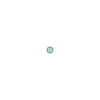

In [19]:
# Hand off to Shapely for GIS operations
shapely_pt = mt_sharp.to_shapely()
print(f"Shapely: {shapely_pt}")
print(f"Type: {type(shapely_pt).__module__}.{type(shapely_pt).__name__}")
shapely_pt  # renders as SVG in Jupyter

## Sun Direction Indicator

The `planetarypy.plotting` module provides `add_sun_indicator` and `imshow_with_sun` for displaying images with a sun direction overlay. The indicator expects the solar azimuth **clockwise from image top** (CW-from-top).

### Azimuth conventions

Different data sources use different zero directions:

| Source | Convention | Zero direction | Convert to CW-from-top |
|--------|-----------|---------------|----------------------|
| `planetarypy.plotting` | CW from top | Up (12 o'clock) | Use directly |
| HiRISE index (`SUB_SOLAR_AZIMUTH`) | CW from right | Right (3 o'clock) | `(az + 90) % 360` |
| Standard geographic | CW from north | North | Depends on image orientation |

The HiRISE convention (CW from 3 o'clock) is documented in the [HiRISE EDR/RDR SIS](https://hirise-pds.lpl.arizona.edu/PDS/DOCUMENT/HIRISE_EDR_RDR_VOL_SIS.PDF) and the [ASU HiRISE glossary](https://viewer.mars.asu.edu/glossary/hirise). Both `SUB_SOLAR_AZIMUTH` and `NORTH_AZIMUTH` use this convention.

In [20]:
import matplotlib.pyplot as plt
from planetarypy.plotting import imshow_with_sun, imshow_gray, add_sun_indicator

### Verification with real HiRISE data

Let's verify the sun indicator against a real HiRISE RDR browse image with clearly visible shadows. We'll use `ESP_013807_2035` — a mid-latitude observation with prominent crater shadows.

The browse image (`.abrowse.jpg`) is the map-projected RDR, so it uses the RDR index metadata. In HiRISE's equirectangular RDRs, `NORTH_AZIMUTH=270°` (CW from right), meaning north has been rotated to the top of the image.

In [21]:
from planetarypy.instruments.mro.hirise import get_browse, get_metadata, sun_azimuth_from_top

# Look up solar geometry from the HiRISE RDR index
meta = get_metadata("ESP_013807_2035_RED")

print(f"Observation: {meta['PRODUCT_ID']}")
print(f"SUB_SOLAR_AZIMUTH: {meta['SUB_SOLAR_AZIMUTH']:.1f}° (CW from 3 o'clock)")
print(f"NORTH_AZIMUTH:     {meta['NORTH_AZIMUTH']:.1f}° (CW from 3 o'clock)")
print(f"INCIDENCE_ANGLE:   {meta['INCIDENCE_ANGLE']:.1f}°")
print(f"MAP_PROJECTION:    {meta['MAP_PROJECTION_TYPE']}")

Observation: ESP_013807_2035_RED
SUB_SOLAR_AZIMUTH: 129.3° (CW from 3 o'clock)
NORTH_AZIMUTH:     270.0° (CW from 3 o'clock)
INCIDENCE_ANGLE:   56.0°
MAP_PROJECTION:    EQUIRECTANGULAR


In [22]:
import matplotlib.image as mpimg

# Download the clean (unannotated) browse — better for image analysis
# Equivalent to: plp hibrowse --clean ESP_013807_2035_RED
browse_path = get_browse("ESP_013807_2035_RED", annotated=False)
img = mpimg.imread(str(browse_path))
print(f"Browse image: {browse_path.name}")
print(f"Size: {img.shape[1]}×{img.shape[0]} pixels")

Browse image: ESP_013807_2035_RED.browse.jpg
Size: 2048×5959 pixels


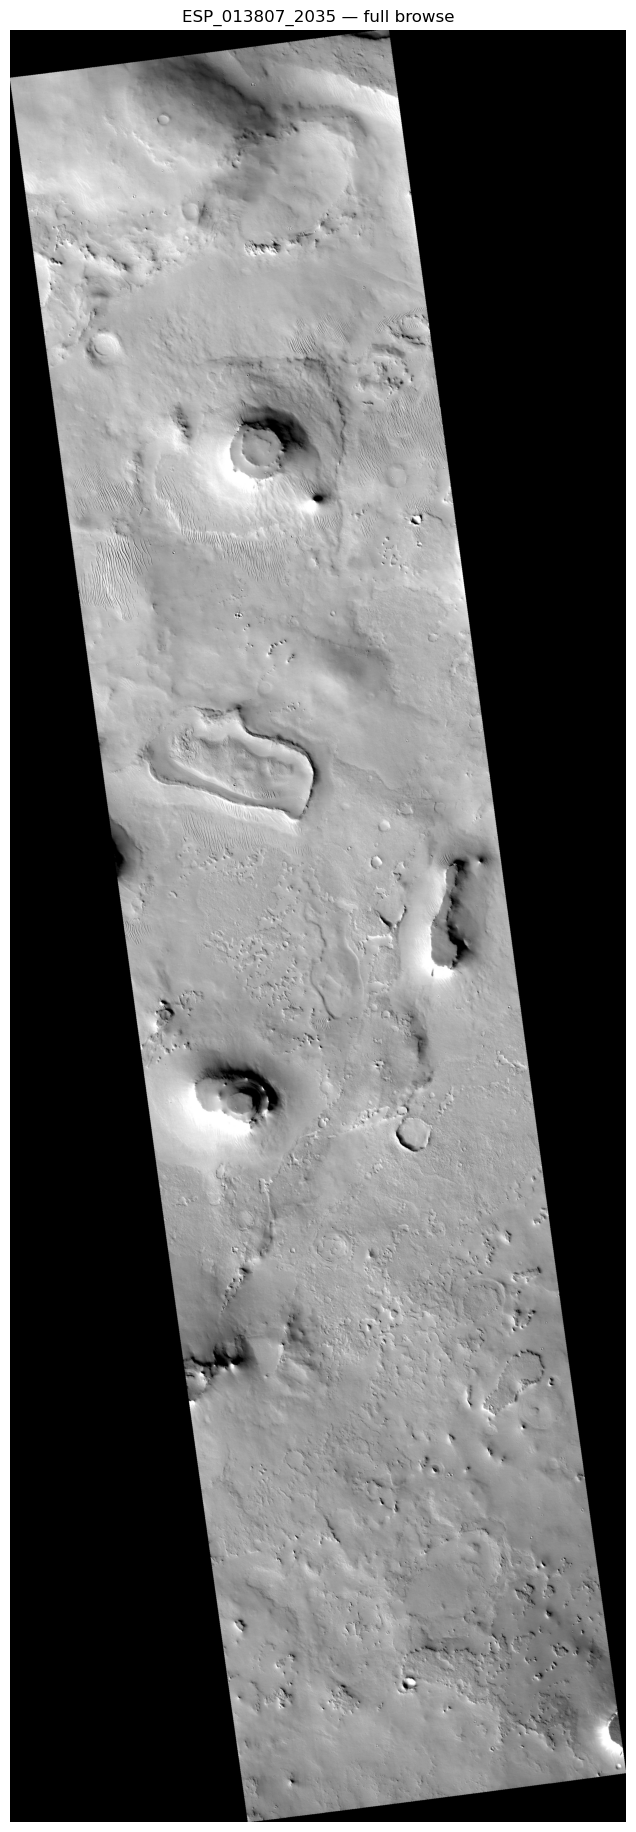

In [23]:
# imshow_gray: quick display with automatic percentile stretch
# HiRISE images are well-behaved — a gentle 0.5-99.5 stretch is usually enough
ax = imshow_gray(img, stretch="0.5,99.5", title="ESP_013807_2035 — full browse")
plt.show()

In [24]:
# Convert HiRISE azimuth to our plotting convention in one call
sun_az_from_top = sun_azimuth_from_top("ESP_013807_2035_RED")

print(f"HiRISE SUB_SOLAR_AZIMUTH: {meta['SUB_SOLAR_AZIMUTH']:.1f}° (CW from right)")
print(f"Converted to CW from top: {sun_az_from_top:.1f}°")
print("\nShadows should point AWAY from the sun indicator.")

HiRISE SUB_SOLAR_AZIMUTH: 129.3° (CW from right)
Converted to CW from top: 219.3°

Shadows should point AWAY from the sun indicator.


<Axes: title={'center': 'ESP_013807_2035 — SUB_SOLAR_AZIMUTH=129.3° → 219.3° from top'}>

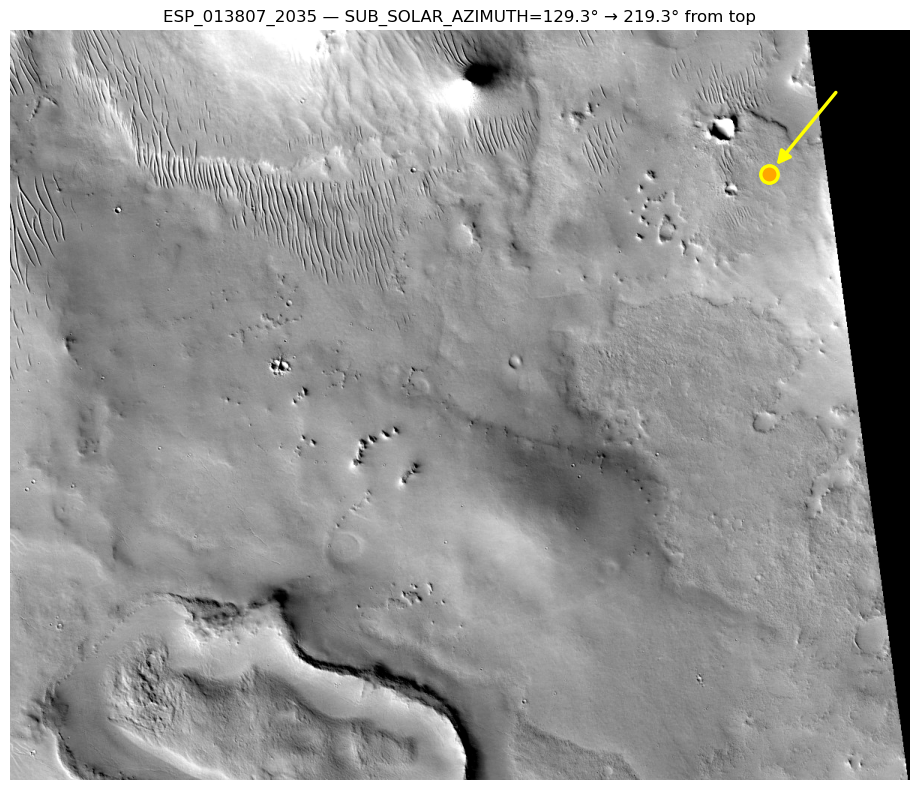

In [25]:
# Crop a window with clear crater shadows (middle of the image)
window = img[1500:2500, 400:1600]

fig, ax = plt.subplots(figsize=(10, 8))
imshow_with_sun(window, sun_az_from_top, stretch="0.5,99.5",
                title=f"ESP_013807_2035 — SUB_SOLAR_AZIMUTH={meta['SUB_SOLAR_AZIMUTH']:.1f}° → {sun_az_from_top:.1f}° from top",
                ax=ax)
fig.tight_layout()
plt.show()

Text(0.5, 1.0, 'Manual plot + sun indicator added separately')

<Axes: title={'center': 'Manual plot + sun indicator added separately'}>

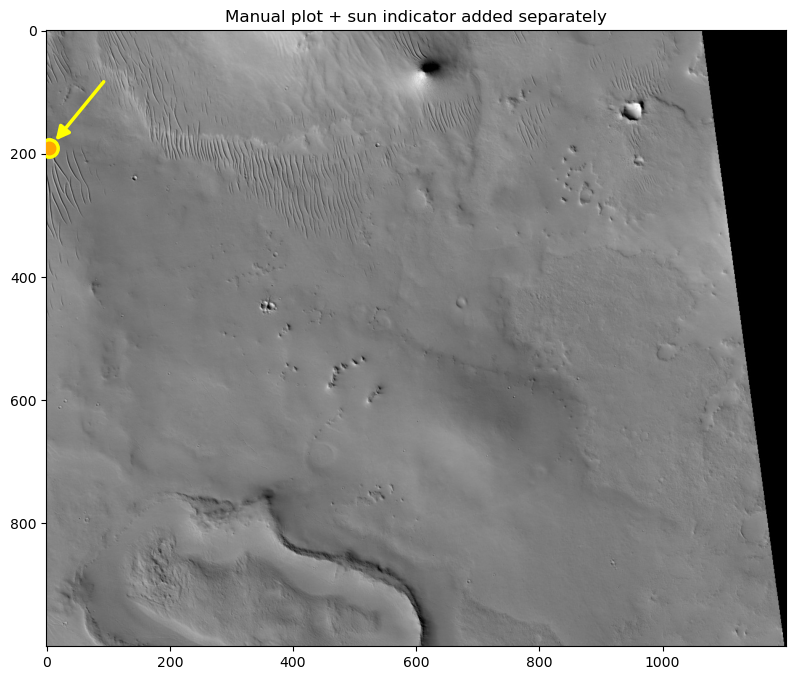

In [26]:
# add_sun_indicator can be added to any existing axes
# Useful when you've already built a plot with other overlays
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(window, cmap="gray")
ax.set_title("Manual plot + sun indicator added separately")
add_sun_indicator(ax, sun_az_from_top, position="upper left")
plt.show()

## Next Steps

We are planning to incorporate a `planetarypy` CRS module written by Christian Tai Udovicic that will enable easy access to all major solar system CRSs.

Other planned features:

- Verify the sun indicator convention for **unprojected EDR** images (RDR convention is verified: `(hirise_az + 90) % 360`)
- Independent sun azimuth calculation via SPICE to validate index values
- Automatic sun indicator from PDS index metadata (no manual conversion)
- Sun indicator support for CTX images (using `SUB_SOLAR_AZIMUTH` from CTX index)